# Exemplo: Ensembles
--------------------

Este exemplo mostra como usar as técnicas de ensemble do experionml para melhorar predições em um conjunto de dados combinando vários modelos.

Importe o conjunto de dados de câncer de mama de [sklearn.datasets](https://scikit-learn.org/stable/datasets/index.html#wine-dataset). Este é um conjunto de dados pequeno e fácil de treinar cujo objetivo é prever se uma paciente tem câncer de mama ou não.

## Carregar os dados

In [1]:
# Import packages
from sklearn.datasets import load_breast_cancer
from experionml import ExperionMLClassifier

In [2]:
# Carregar os dados
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

## Executar o pipeline

In [3]:
# Inicialize o experionml e treine vários modelos
experionml = ExperionMLClassifier(X, y, holdout_size=0.2, verbose=2, random_state=1)
experionml.run(models=["LR", "Tree", "LGB"], metric="accuracy")

<< ================== ExperionML ================== >>

Configuração ==================== >>
Tarefa do algoritmo: Binary classification.

Estatísticas do conjunto de dados ==================== >>
Formato: (456, 31)
Tamanho do conjunto de train: 343
Tamanho do conjunto de test: 113
Tamanho do conjunto de holdout: 113
-------------------------------------
Memória: 113.22 kB
Escalonado: False
Valores atípicos: 124 (1.2%)


Training ========================= >>
Models: LR, Tree, LGB
Metric: accuracy




Results for LogisticRegression:
Fit ---------------------------------------------


Train evaluation --> accuracy: 0.9913


Test evaluation --> accuracy: 0.9823
Time elapsed: 1.460s


-------------------------------------------------
Time: 1.460s


Results for DecisionTree:
Fit ---------------------------------------------
Train evaluation --> accuracy: 1.0
Test evaluation --> accuracy: 0.9558
Time elapsed: 0.044s
-------------------------------------------------
Time: 0.044s


Results for LightGBM:
Fit ---------------------------------------------


Train evaluation --> accuracy: 1.0


Test evaluation --> accuracy: 0.9558
Time elapsed: 0.807s


-------------------------------------------------
Time: 0.807s


Resultados finais ==================== >>
Tempo total: 3.093s
-------------------------------------


LogisticRegression --> accuracy: 0.9823 !
DecisionTree       --> accuracy: 0.9558


LightGBM           --> accuracy: 0.9558


## Voting

In [4]:
# Combine os modelos em um modelo Voting
experionml.voting(voting="soft")

Results for Voting:
Fit ---------------------------------------------


Train evaluation --> accuracy: 1.0
Test evaluation --> accuracy: 0.9735
Time elapsed: 0.931s


In [5]:
# Observe que agora temos um modelo extra no pipeline
experionml.models

['LR', 'Tree', 'LGB', 'Vote']

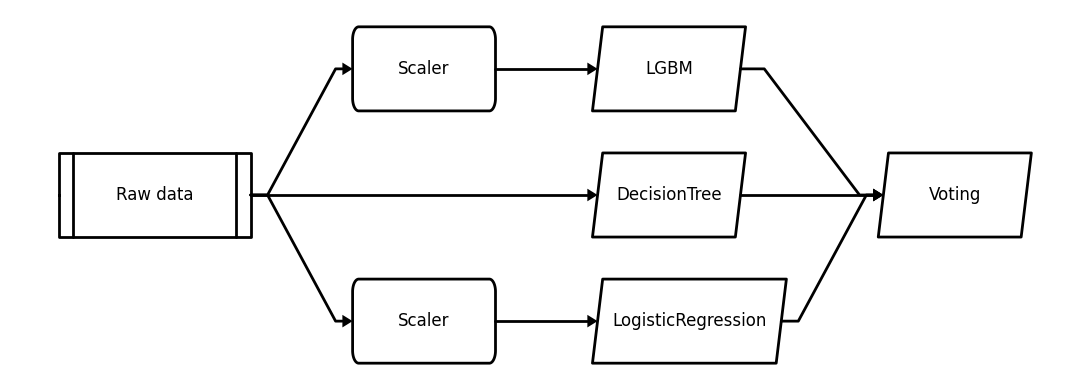

In [6]:
# O método plot_pipeline ajuda a visualizar o ensemble
experionml.plot_pipeline()

In [7]:
# Podemos usá-lo como qualquer outro modelo para fazer predições ou gráficos
experionml.vote.predict_proba("test")

,0,1
343,0.000010,0.999990
344,0.999989,0.000011
345,0.999988,0.000012
346,0.000175,0.999825
347,0.001798,0.998202
...,...,...
451,0.997818,0.002182
452,0.010445,0.989555
453,0.999987,0.000013
454,0.000325,0.999675


In [8]:
experionml.vote.plot_threshold(metric=["auc", "recall", "accuracy"])

In [9]:
experionml.plot_results(legend=None)

In [10]:
experionml.delete("vote")

Deleting 1 models...
 --> Model Vote successfully deleted.


## Stacking

Assim como no Voting, podemos criar um modelo Stacking. Usar `train_on_test=True` treina o estimador final no conjunto de teste para evitar overfitting no conjunto de treino.

In [11]:
experionml.stacking(final_estimator="LDA", train_on_test=True)

Results for Stacking:
Fit ---------------------------------------------
Train evaluation --> accuracy: 0.9942


Test evaluation --> accuracy: 0.9735
Time elapsed: 0.239s


In [12]:
# Agora usamos o conjunto holdout para avaliar o desempenho do modelo Stack
experionml.stack.results

accuracy_train      0.9942
accuracy_test       0.9735
accuracy_holdout    0.9823
time_fit            0.2394
time                0.2394
Name: Stack, dtype: float64

In [13]:
experionml.plot_results(rows="holdout", legend=None)

In [14]:
experionml.stack.plot_roc(rows="holdout")

In [15]:
# Novamente, o modelo pode ser usado para predições ou gráficos
experionml.stack.predict(X)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

PermutationExplainer explainer:   2%|▎                  | 2/113 [00:00<?, ?it/s]

PermutationExplainer explainer:   4%|▍          | 4/113 [00:11<01:34,  1.16it/s]

PermutationExplainer explainer:   4%|▍          | 5/113 [00:13<02:20,  1.30s/it]

PermutationExplainer explainer:   5%|▌          | 6/113 [00:15<02:32,  1.43s/it]

PermutationExplainer explainer:   6%|▋          | 7/113 [00:17<02:48,  1.59s/it]

...

PermutationExplainer explainer:  98%|████████▊| 111/113 [03:14<00:03,  1.66s/it]

PermutationExplainer explainer:  99%|████████▉| 112/113 [03:16<00:01,  1.75s/it]

PermutationExplainer explainer: 100%|█████████| 113/113 [03:18<00:00,  1.76s/it]

PermutationExplainer explainer: 114it [03:20,  1.83s/it]                        

PermutationExplainer explainer: 114it [03:20,  1.79s/it]

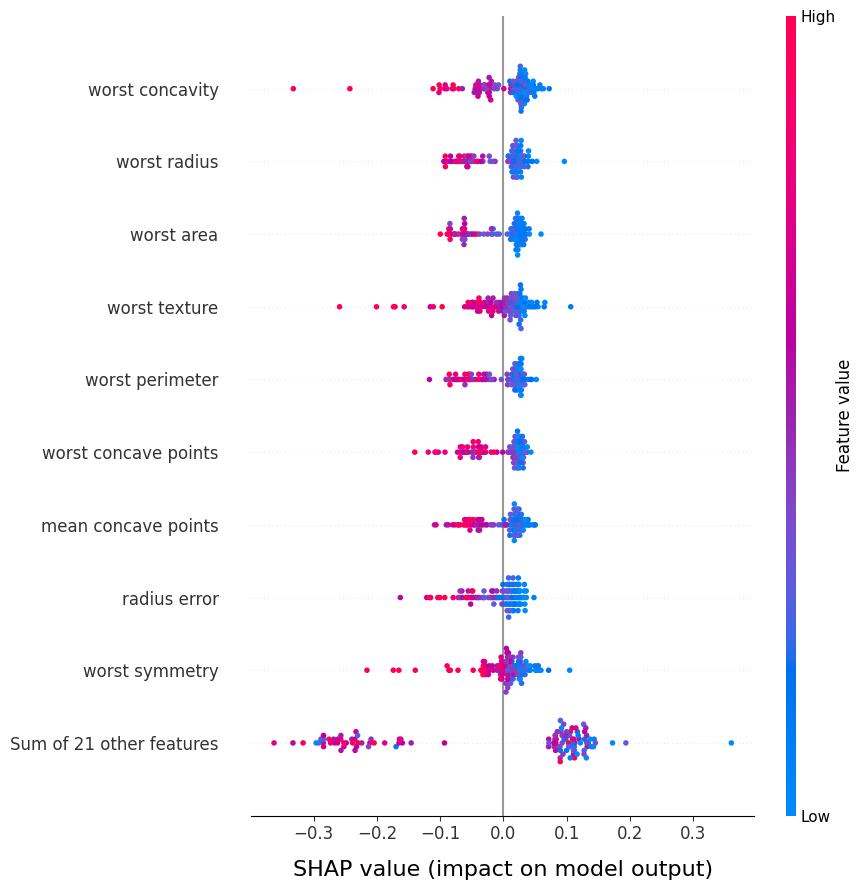

In [16]:
experionml.stack.plot_shap_beeswarm(show=10)